<a href="https://colab.research.google.com/github/CodeWithSudhanshu/PCI-Plume-Project/blob/main/PCI_Plume_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

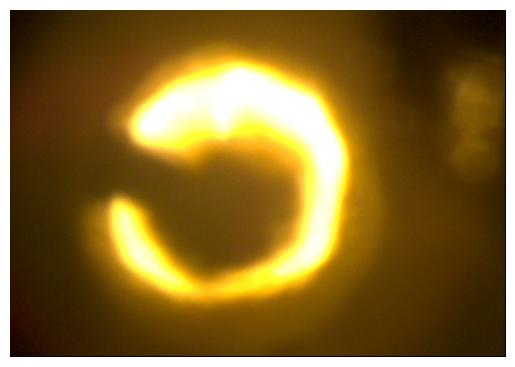

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img1.jpeg")

# convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [ ]:
print(img.shape)             # image height , image width , color channels

(350, 500, 3)


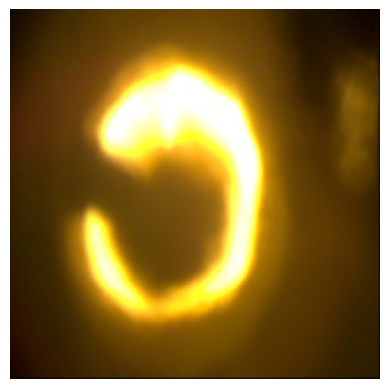

In [ ]:
img_resized = cv2.resize(img_rgb, (256, 256))

plt.imshow(img_resized)         #resizing bcz deep learning models use fixed sizing
plt.axis("off")                 # 128 x 128 , 256 x 256 , 512 x 512
plt.show()

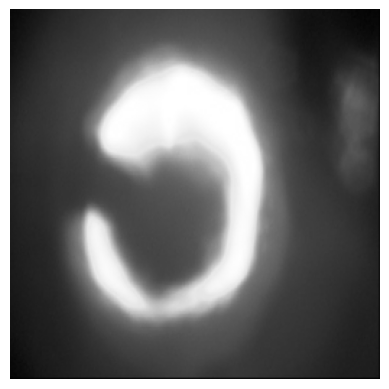

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img1.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (256, 256))

gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)   # convert to grayscale

plt.imshow(gray, cmap='gray')
plt.axis("off")
plt.show()

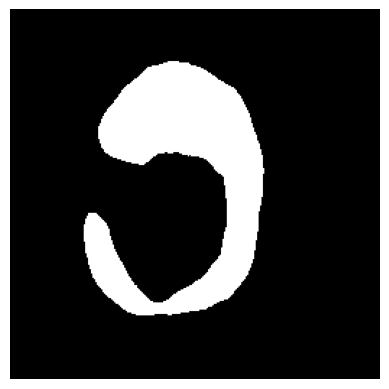

In [ ]:
_, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.axis("off")
plt.show()

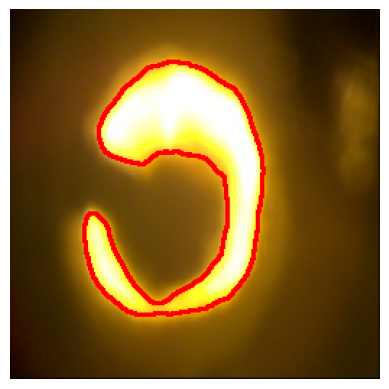

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img1.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (256, 256))
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

_, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contour_img = img_resized.copy()   #drawing contour

cv2.drawContours(contour_img, contours, -1, (255, 0, 0), 2)

plt.imshow(contour_img)
plt.axis("off")
plt.show()



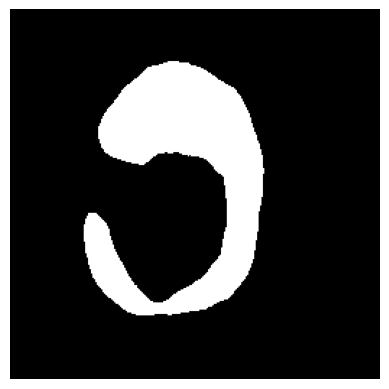

In [ ]:
import numpy as np

mask = np.zeros(gray.shape, dtype=np.uint8)    #creating empty black img..

cv2.drawContours(mask, contours, -1, 255, thickness=cv2.FILLED)  #filling contour with white clrr

plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
import os

print(os.listdir())

['.config', 'img15.jpeg', 'img1.jpeg', 'img2.jpeg', 'img5.jpeg', 'img10.jpeg', 'img7.jpeg', 'img12.jpeg', 'img14.jpeg', 'img8.jpeg', 'img4.jpeg', 'img9.jpeg', 'img3.jpeg', 'img13.jpeg', 'img11.jpeg', 'img6.jpeg', 'sample_data']


In [ ]:
import os

os.makedirs("masks", exist_ok=True)

print("Masks folder is now created")

Masks folder is now created


In [ ]:
import cv2
import os
import numpy as np

for file in os.listdir():

    if file.endswith(".jpeg"):

        img = cv2.imread(file)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (256, 256))
        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

        _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)   #thresholding

        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )
        mask = np.zeros(gray.shape, dtype=np.uint8)

        cv2.drawContours(    #filling the colours
            mask,
            contours,
            -1,
            255,
            thickness=cv2.FILLED
        )

        save_path = os.path.join("masks", file)  #saving images as mask image
        cv2.imwrite(save_path, mask)
        print(f"Processed: {file}")

Processed: img15.jpeg
Processed: img1.jpeg
Processed: img2.jpeg
Processed: img5.jpeg
Processed: img10.jpeg
Processed: img7.jpeg
Processed: img12.jpeg
Processed: img14.jpeg
Processed: img8.jpeg
Processed: img4.jpeg
Processed: img9.jpeg
Processed: img3.jpeg
Processed: img13.jpeg
Processed: img11.jpeg
Processed: img6.jpeg


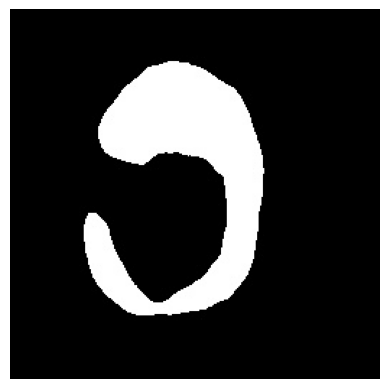

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

mask_path = "masks/img1.jpeg"

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
import os

print(os.listdir("masks"))

['img15.jpeg', 'img1.jpeg', 'img2.jpeg', 'img5.jpeg', 'img10.jpeg', 'img7.jpeg', 'img12.jpeg', 'img14.jpeg', 'img8.jpeg', 'img4.jpeg', 'img9.jpeg', 'img3.jpeg', 'img13.jpeg', 'img11.jpeg', 'img6.jpeg']


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/PCI-PROJECT"

folders = [
    "images",
    "masks",
    "annotations",
    "notebooks",
    "models"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)
print("This creates the project folder.")

This creates the project folder.


In [ ]:
image_path = "/content/drive/MyDrive/PCI-PROJECT/images/PCI images"

print(os.listdir(image_path))

['img13.jpeg', 'img15.jpeg', 'img10.jpeg', 'img3.jpeg', 'img8.jpeg', 'img12.jpeg', 'img7.jpeg', 'img6.jpeg', 'img4.jpeg', 'img2.jpeg', 'img11.jpeg', 'img9.jpeg', 'img5.jpeg', 'img1.jpeg', 'img14.jpeg']


In [ ]:
import cv2
import os
import numpy as np

image_path = "/content/drive/MyDrive/PCI-PROJECT/images/PCI images"

mask_path = "/content/drive/MyDrive/PCI-PROJECT/masks"

for file in os.listdir(image_path):

    if file.endswith(".jpeg"):

        img_full_path = os.path.join(image_path, file)

        img = cv2.imread(img_full_path)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_resized = cv2.resize(img_rgb, (256, 256))   #resizing is always important

        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

        _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        mask = np.zeros(gray.shape, dtype=np.uint8)

        cv2.drawContours(
            mask,
            contours,
            -1,
            255,
            thickness=cv2.FILLED
        )

        save_path = os.path.join(mask_path, file)

        cv2.imwrite(save_path, mask)

        print(f"Processed: {file}")

Processed: img13.jpeg
Processed: img15.jpeg
Processed: img10.jpeg
Processed: img3.jpeg
Processed: img8.jpeg
Processed: img12.jpeg
Processed: img7.jpeg
Processed: img6.jpeg
Processed: img4.jpeg
Processed: img2.jpeg
Processed: img11.jpeg
Processed: img9.jpeg
Processed: img5.jpeg
Processed: img1.jpeg
Processed: img14.jpeg


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install labelme

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.7/594.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 995.9/995.9 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


In [7]:
import os
train_json_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"
print(os.listdir(train_json_path))

['img1.json', 'img2.json', 'img3.json']


In [19]:
import os
import json
import cv2
import numpy as np

train_json_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"

json_files = [f for f in os.listdir(train_json_path) if f.endswith(".json")]

for file in json_files:

    json_path = os.path.join(train_json_path, file)

    with open(json_path, 'r') as f:
        data = json.load(f)                            # here we are converting polygon annotations into binary masks

    image_height = data['imageHeight']                 # for every .json file polygon coordinates ko we have converted into black-white mask image using OpenCV polygon filling.
    image_width = data['imageWidth']

    mask = np.zeros((image_height, image_width), dtype=np.uint8)

    for shape in data['shapes']:

        points = np.array(shape['points'], dtype=np.int32)

        cv2.fillPoly(mask, [points], 255)

    output_name = file.replace(".json", "_mask.png")

    output_path = os.path.join(train_json_path, output_name)

    cv2.imwrite(output_path, mask)

    print(f"Mask created: {output_name}")

Mask created: img1_mask.png
Mask created: img2_mask.png
Mask created: img3_mask.png


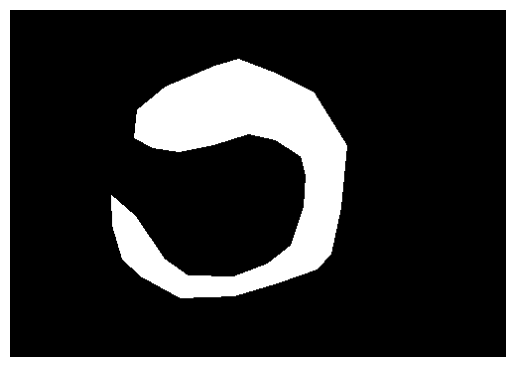

In [20]:
import matplotlib.pyplot as plt

mask_path = "/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks/img1_mask.png"

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(mask, cmap='gray')
plt.axis("off")
plt.show()

In [21]:
!pip install torch torchvision

In [23]:
import torch
from torch.utils.data import Dataset      # humne Pytorch install kra bcz it tells the AI model where images,masks are and how to load them . Iske bina our model can't be train !
import cv2
import os

class PlumeDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = os.listdir(image_dir)

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(
            self.image_dir,
            self.images[index]
        )

        mask_name = self.images[index].replace(".jpeg", "_mask.png")

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = cv2.imread(img_path)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        return image, mask



In [24]:
train_dataset = PlumeDataset(   #creating dataset object

    image_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/images",

    mask_dir="/content/drive/MyDrive/PCI-PROJECT/datasets/training/masks"
)
print(len(train_dataset))

3
